In [ ]:
# Author: Houxuan Zhang
# All code in this notebook was written by houxuan zhang.


# 第1段：导入库 + 设置设备 + 数据增强设置
# 1: Import library + Set device + Data enhancement Settings
import torchvision
from torch.utils.tensorboard import SummaryWriter
import os
import time
from torch import nn
from torch.utils.data import DataLoader
import torch
from torchvision.models import resnet18
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置训练设备 / Set training device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 设置随机种子确保可重复性 / Set random seed for reproducibility
torch.manual_seed(42)
# 归一化参数 / Normalization parameters
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

# 数据增强 / Data augmentation
transform_train = torchvision.transforms.Compose([
    torchvision.transforms.RandomCrop(32, padding=4), # 随机裁剪 / Random crop
    torchvision.transforms.RandomHorizontalFlip(),  # 随机水平翻转 / Random horizontal flip
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean, std) # 标准化 / Normalization
])

# 测试集归一化 / Test set normalization
transform_test = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean, std)
])


In [7]:
# 下载CIFAR10数据集 / Download CIFAR-10 dataset
train_data = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform_train, download=True)
test_data = torchvision.datasets.CIFAR10(root="./data", train=False, transform=transform_test, download=True)
# 构建数据加载器 / Build DataLoaders
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64)


In [10]:
# 第3段：通用训练和测试函数 train_and_evaluate()
# 3: General training and test functions
def train_and_evaluate(model, model_name):
    model.to(device)
    # 损失函数 / Loss function
    loss_fn = nn.CrossEntropyLoss().to(device)
    # 优化器 / Optimizer
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
    # 日志记录 / TensorBoard logging
    writer = SummaryWriter(f"./logs_{model_name}")
    total_train_step = 0
    total_test_step = 0
    epochs = 10
    start_time = time.time()

    os.makedirs(f"model_save_{model_name}", exist_ok=True)

    for epoch in range(epochs):
        print(f"---- Training {model_name} | Epoch {epoch + 1} ----")
        model.train()
        for data in train_dataloader:
            imgs, targets = data
            imgs, targets = imgs.to(device), targets.to(device)

            outputs = model(imgs)
            loss = loss_fn(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_step += 1
            if total_train_step % 100 == 0:
                duration = time.time() - start_time
                print(f"{duration:.2f}s - Step:{total_train_step}, Loss:{loss.item():.4f}")
                writer.add_scalar("train_loss", loss.item(), total_train_step)

        # 测试阶段
        # test
        model.eval()
        total_test_loss = 0
        total_accuracy = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for data in test_dataloader:
                imgs, targets = data
                imgs, targets = imgs.to(device), targets.to(device)
                outputs = model(imgs)
                loss = loss_fn(outputs, targets)
                total_test_loss += loss.item()

                preds = outputs.argmax(1)
                total_accuracy += (preds == targets).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        acc = total_accuracy / len(test_data)
        print(f"Test Loss: {total_test_loss:.4f}, Test Accuracy: {acc:.4f}")
        writer.add_scalar("test_loss", total_test_loss, total_test_step)
        writer.add_scalar("test_accuracy", acc, total_test_step)
        total_test_step += 1

        torch.save(model, f"model_save_{model_name}/{model_name}_epoch{epoch}.pth")

    writer.close()
    return acc, total_test_loss, all_preds, all_targets


In [11]:
# 第4段：定义并训练两个模型
# 4: Define and train two models

# 原始 ResNet18 模型 / Base ResNet18 model
resnet_base = resnet18(pretrained=False)
resnet_base.fc = nn.Linear(512, 10)
acc_base, loss_base, preds_base, targets_base = train_and_evaluate(resnet_base, "resnet18_base")

# 改进 ResNet18 模型 / Improved ResNet18 with Dropout
# 加载ResNet18模型并修改输出层 / Load ResNet18 model and modify output layer
resnet_improved = resnet18(pretrained=False)
resnet_improved.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)
acc_improved, loss_improved, preds_improved, targets_improved = train_and_evaluate(resnet_improved, "resnet18_improved")


---- Training resnet18_base | Epoch 1 ----
3.72s - Step:100, Loss:2.0555
6.69s - Step:200, Loss:1.9311
9.67s - Step:300, Loss:1.5410
12.63s - Step:400, Loss:1.5887
16.16s - Step:500, Loss:1.6474
19.13s - Step:600, Loss:1.5687
22.08s - Step:700, Loss:1.3351
Test Loss: 239.0353, Test Accuracy: 0.4349
---- Training resnet18_base | Epoch 2 ----
28.63s - Step:800, Loss:1.6712
31.57s - Step:900, Loss:1.4649
34.56s - Step:1000, Loss:1.3992
37.90s - Step:1100, Loss:1.8288
41.23s - Step:1200, Loss:1.6885
44.25s - Step:1300, Loss:1.6862
47.29s - Step:1400, Loss:1.4621
50.94s - Step:1500, Loss:1.5784
Test Loss: 216.9202, Test Accuracy: 0.4947
---- Training resnet18_base | Epoch 3 ----
56.92s - Step:1600, Loss:1.1756
59.91s - Step:1700, Loss:1.4968
63.60s - Step:1800, Loss:1.3734
66.63s - Step:1900, Loss:1.3469
69.61s - Step:2000, Loss:1.3452
72.59s - Step:2100, Loss:1.3483
76.14s - Step:2200, Loss:1.2589
79.07s - Step:2300, Loss:1.3491
Test Loss: 200.1361, Test Accuracy: 0.5493
---- Training resn

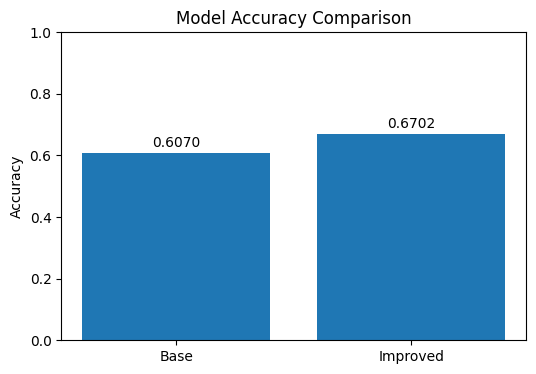

Base Model Classification Report:
              precision    recall  f1-score   support

    airplane       0.61      0.73      0.66      1000
  automobile       0.75      0.73      0.74      1000
        bird       0.57      0.52      0.55      1000
         cat       0.51      0.40      0.45      1000
        deer       0.50      0.58      0.54      1000
         dog       0.57      0.52      0.54      1000
        frog       0.59      0.54      0.56      1000
       horse       0.67      0.69      0.68      1000
        ship       0.62      0.81      0.70      1000
       truck       0.67      0.56      0.61      1000

    accuracy                           0.61     10000
   macro avg       0.61      0.61      0.60     10000
weighted avg       0.61      0.61      0.60     10000

Improved Model Classification Report:
              precision    recall  f1-score   support

    airplane       0.71      0.73      0.72      1000
  automobile       0.83      0.74      0.78      1000
      

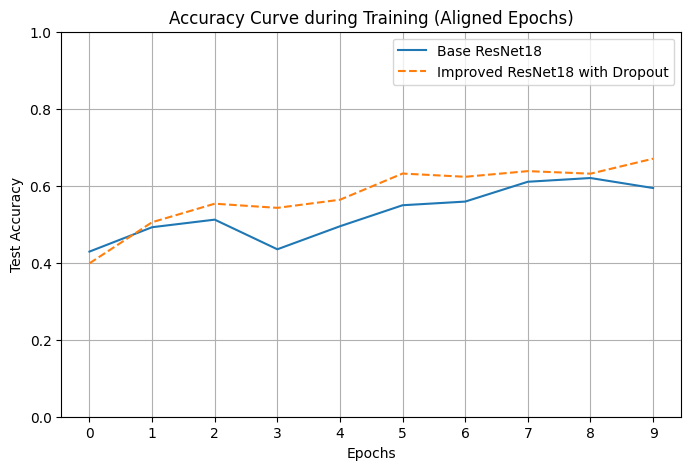

In [24]:
# 第5段：准确率对比图、分类报告、准确率变化图
# Accuracy comparison chart, classification report, accuracy change chart
# 准确率对比图 / Accuracy Comparison Bar Chart
plt.figure(figsize=(6, 4))
bars = plt.bar(["Base", "Improved"], [acc_base, acc_improved])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.show()


# 输出分类报告 / Classification Report
print("Base Model Classification Report:")
print(classification_report(targets_base, preds_base, target_names=test_data.classes))

print("Improved Model Classification Report:")
print(classification_report(targets_improved, preds_improved, target_names=test_data.classes))



from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

# 从日志中提取 test_accuracy 的值 / Extract scalar values from TensorBoard logs
def extract_scalar_from_event(log_dir, tag="test_accuracy"):
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()
    scalar_list = event_acc.Scalars(tag)
    values = [x.value for x in scalar_list]
    return values

acc_base_list = extract_scalar_from_event("./logs_resnet18_base", tag="test_accuracy")
acc_impr_list = extract_scalar_from_event("./logs_resnet18_improved", tag="test_accuracy")

epochs = list(range(min(len(acc_base_list), len(acc_impr_list))))

acc_base_list = acc_base_list[:len(epochs)]
acc_impr_list = acc_impr_list[:len(epochs)]

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc_base_list, label="Base ResNet18")
plt.plot(epochs, acc_impr_list, label="Improved ResNet18 with Dropout", linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")
plt.title("Accuracy Curve during Training (Aligned Epochs)")
plt.legend()
plt.grid(True)
plt.ylim(0, 1.0)
plt.xticks(epochs)
plt.show()

